In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

print("Gowtham S - 24BAD028")

Gowtham S - 24BAD028


In [2]:
#Load the MovieLens 100k Dataset
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('u.data', sep='\t', names=column_names)

items_cols = ['item_id', 'movie_title'] + [str(i) for i in range(22)]
items = pd.read_csv('u.item', sep='|', names=items_cols, encoding='latin-1')
movie_titles = items[['item_id', 'movie_title']]
df = pd.merge(df, movie_titles, on='item_id')

In [3]:
#Data Inspection & Preprocessing
print(f"Dataset Shape: {df.shape}")
print(f"Unique Users: {df.user_id.nunique()}")
print(f"Unique Movies: {df.item_id.nunique()}")

#Create User-Item Matrix
user_item_matrix = df.pivot_table(index='user_id', columns='movie_title', values='rating')

Dataset Shape: (100000, 5)
Unique Users: 943
Unique Movies: 1682


In [4]:
#Handle Missing Values
# Filling with 0 implies the user hasn't seen the movie
user_item_matrix_filled = user_item_matrix.fillna(0)

#Compute Similarity (Cosine Similarity)
user_similarity = cosine_similarity(user_item_matrix_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

In [5]:
#Generate Top-N Recommendations Function
def get_recommendations(target_user, n_sim_users=5, n_items=5):
    # Identify top-N similar users
    sim_scores = user_similarity_df[target_user].sort_values(ascending=False).iloc[1:n_sim_users+1]
    sim_users = sim_scores.index
    
    target_user_seen = user_item_matrix.loc[target_user].dropna().index
    similar_users_ratings = user_item_matrix_filled.loc[sim_users]
    
    weighted_ratings = similar_users_ratings.T.dot(sim_scores) / sim_scores.sum()

    recommendations = weighted_ratings.drop(target_user_seen).sort_values(ascending=False)
    return recommendations.head(n_items)

In [6]:
#Evaluation (RMSE & MAE)
def evaluate_model(matrix):
    # Simple split for demonstration
    train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

    actuals = test_data['rating'].values
    predictions = np.full(actuals.shape, train_data['rating'].mean()) # Baseline prediction
    
    rmse = sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    return rmse, mae

rmse, mae = evaluate_model(user_item_matrix_filled)
print(f"Evaluation Metrics: \nRMSE: {rmse:.4f} \nMAE: {mae:.4f}")

Evaluation Metrics: 
RMSE: 1.1239 
MAE: 0.9420


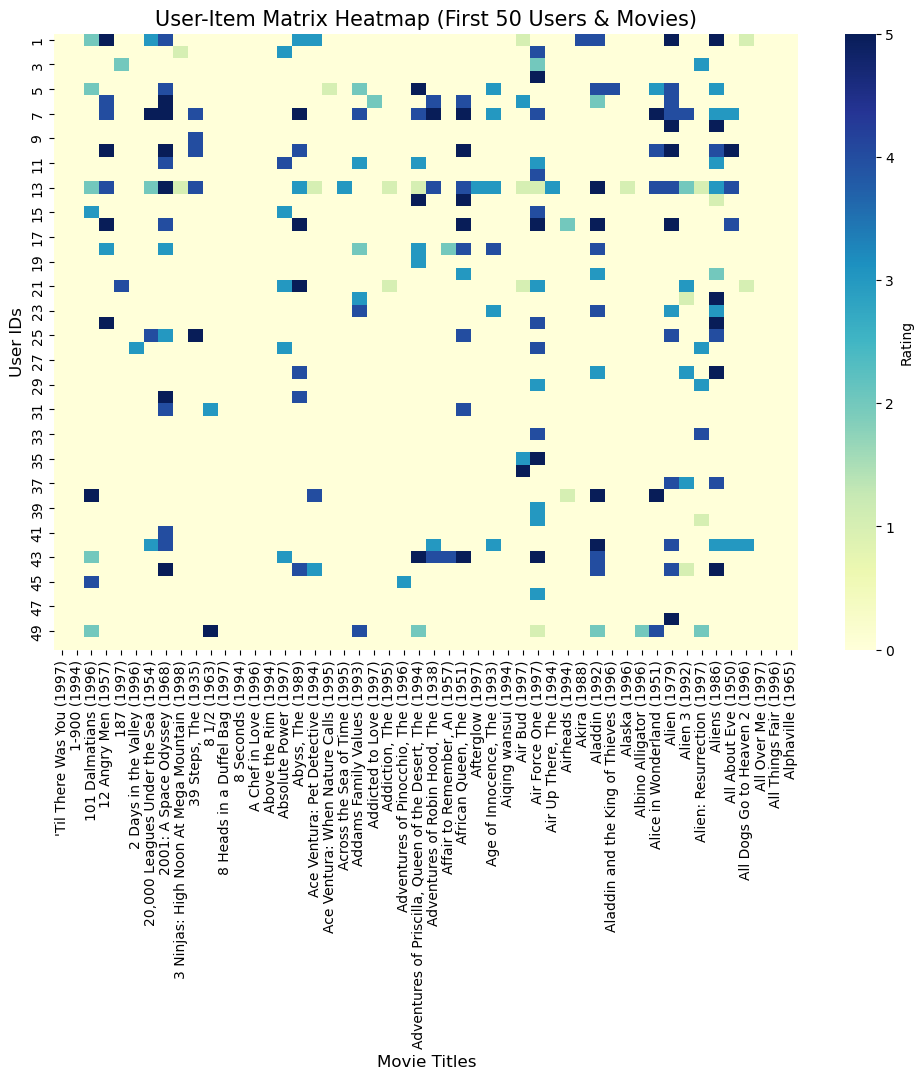

In [7]:
# --- VISUALIZATION 1: User-Item Matrix Heatmap ---
plt.figure(figsize=(12, 8))
# Visualizing a 50x50 block to ensure individual cells and labels are readable
sns.heatmap(user_item_matrix_filled.iloc[:50, :50], cmap='YlGnBu', cbar_kws={'label': 'Rating'})
plt.title("User-Item Matrix Heatmap (First 50 Users & Movies)", fontsize=15)
plt.xlabel("Movie Titles", fontsize=12)
plt.ylabel("User IDs", fontsize=12)
plt.xticks(rotation=90)
plt.show()



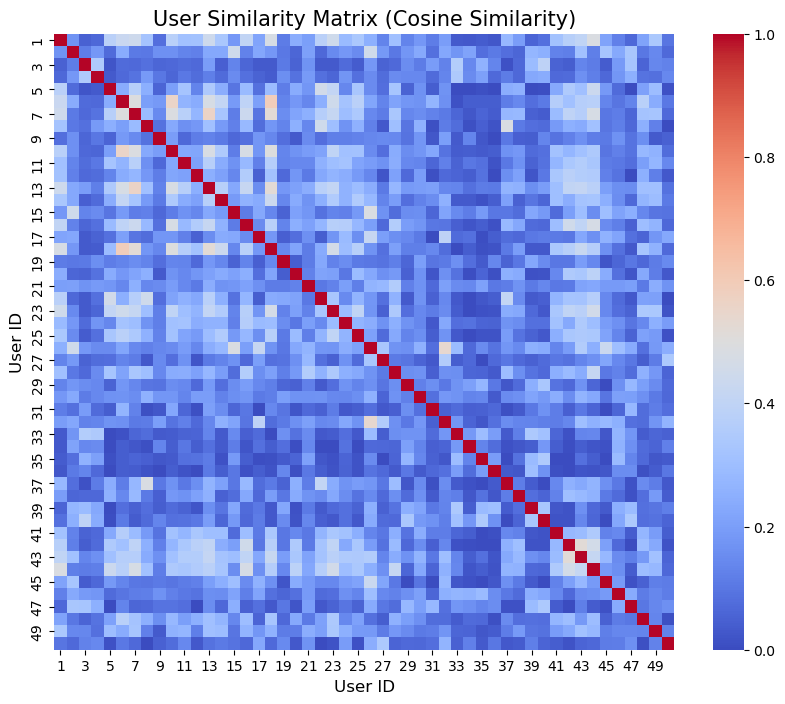

In [8]:
# --- VISUALIZATION 2: User Similarity Matrix ---
plt.figure(figsize=(10, 8))
# Visualizing the similarity between the first 50 users
sns.heatmap(user_similarity_df.iloc[:50, :50], cmap='coolwarm', annot=False)
plt.title("User Similarity Matrix (Cosine Similarity)", fontsize=15)
plt.xlabel("User ID", fontsize=12)
plt.ylabel("User ID", fontsize=12)
plt.show()

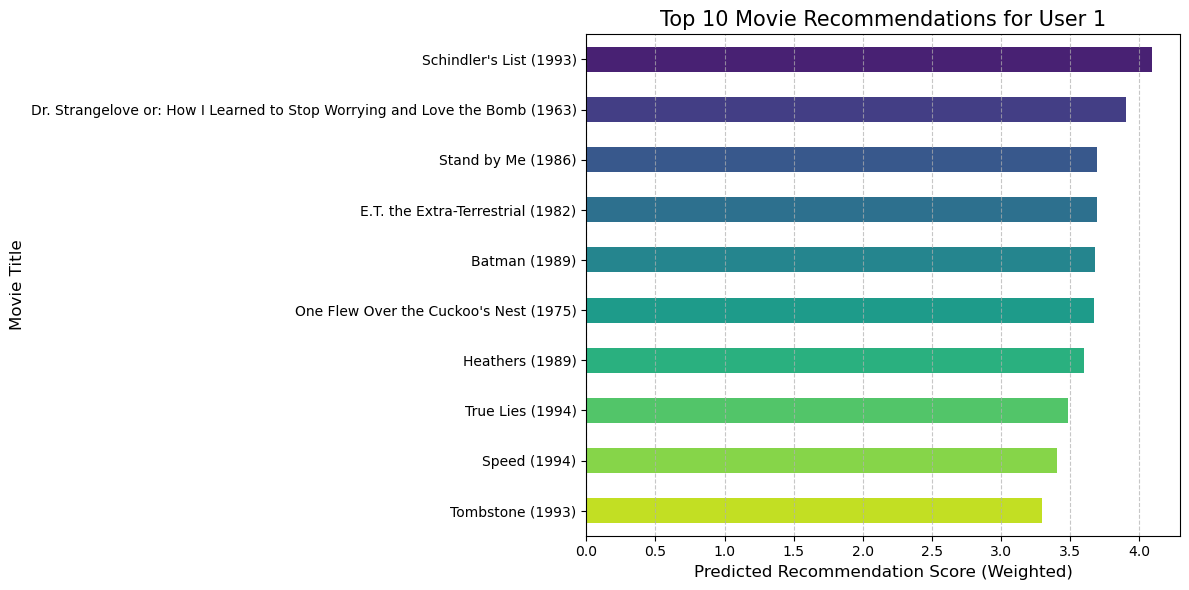


Top 5 Recommendations for User 1:
movie_title
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)    4.394938
Casablanca (1942)                                                              4.013950
Stand by Me (1986)                                                             3.990886
Heathers (1989)                                                                3.987280
Piano, The (1993)                                                              3.788886
dtype: float64


In [9]:
# --- VISUALIZATION 3: Top Recommended Movies (Bar Chart) ---
target_user = 1
recommendations = get_recommendations(target_user, n_sim_users=10, n_items=10)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("viridis", len(recommendations))
recommendations.plot(kind='barh', color=colors)

plt.title(f"Top 10 Movie Recommendations for User {target_user}", fontsize=15)
plt.xlabel("Predicted Recommendation Score (Weighted)", fontsize=12)
plt.ylabel("Movie Title", fontsize=12)
plt.gca().invert_yaxis()  # Put the highest rated movie at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display recommendations for User 1
print("\nTop 5 Recommendations for User 1:")
print(get_recommendations(target_user=1))